In [1]:
# imports
import numpy as np
import pandas as pd
import os
import re
from functools import partial
from itertools import starmap

from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
from scipy.ndimage import uniform_filter as unifilt
from scipy import interpolate
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing.filtering import bipolar_reref, zscore
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils
from iEEG_utils.processing.fooof_mod import fit_group

from pymultitaper import multitaper_spectrogram

from fooof import FOOOF, FOOOFGroup
from fooof.core.funcs import lorentzian_function
from fooof.utils import interpolate_spectra
from fooof.utils.params import compute_time_constant, compute_knee_frequency
from fooof.sim.gen import gen_periodic

# instantiate a random number generator
rng = np.random.default_rng()

C:\Users\jmile3\Documents\GitHub\GRID_lab_python\iEEG_utils\processing\fooof_mod.py:14: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOFGroup


In [4]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

# load each data file
montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

montage = montage.loc[(montage.keep)&(montage.region!="DC_sync"),:]
display(montage)

# Align traces to image onsets
img_ts = origts[events.img_on_ix]
pairs_list = np.array(utils.find_valid_pairs(montage.loc[:,"name"].to_list(),montage["region"].to_list()))

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\ea2142\EmotionTask


,ID,age,region,ch,name,keep
0,ea2142,19.83,r_rostralmiddlefrontal,21,RO_8,True
1,ea2142,19.83,r_rostralmiddlefrontal,22,RO_9,True
2,ea2142,19.83,r_superiorfrontal,34,RQ_8,True
3,ea2142,19.83,r_superiorfrontal,35,RQ_9,True
5,ea2142,19.83,r_Amy,95,RB_2,True
6,ea2142,19.83,r_Amy,96,RB_3,True
8,ea2142,19.83,r_fusiform,99,RB_6,True
9,ea2142,19.83,r_fusiform,100,RB_7,True
10,ea2142,19.83,r_parahippocampal,110,RC_1,True
11,ea2142,19.83,r_parahippocampal,111,RC_2,True


In [180]:
pair = pairs_list[-3]
print(pair)

['RB_2' 'RB_3']


In [181]:
# parameters for signal processing
resrate = 1024
lpfreq = 300
# time prior to (pre) and after (post) image onset
s_pre = -1.5
s_post = 2.5
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

img_cats = ["anger","fear","neutral","happy"]

ts,bipolar,filtwins1 = bipolar_reref(data.loc[:,pair[::-1]],origfs,
                                     resrate,lpfreq=lpfreq,norm=None)

spect_ixs = np.array([np.where((ts>=(im_t+s_pre))&(ts<=(im_t+s_post))) for im_t in img_ts]).squeeze()

t_res = 1/16
t_win = 1
# calculate first spectrogram so I don't have to manually figure df and dt
f,sts,spectra = multitaper_spectrogram(bipolar[spect_ixs[0,:]],resrate,time_step=t_res,
                                       window_length=t_win,NW=3,detrend='off',
                                       freq_range=[0.5, 100],
                                       nfft=2*t_win*resrate, db_scale=False,
                                       boundary_pad=False)
all_spect = np.zeros(shape=spectra.shape+(bipolar[spect_ixs].shape[0],))
all_spect[:,:,0] = spectra

for trial in range(1,bipolar[spect_ixs].shape[0]):
  f,sts,spectra = multitaper_spectrogram(bipolar[spect_ixs[trial,:]],resrate,time_step=t_res,
                                         window_length=t_win,NW=3,detrend='off',
                                         freq_range=[0.5, 100],
                                         nfft=2*t_win*resrate, db_scale=False,
                                         boundary_pad=False)
  all_spect[:,:,trial] = spectra

smoothspect = unifilt(all_spect, [5,3], mode="nearest", axes=[0,1])
intfs = np.concatenate((np.linspace(0.5,1,sum(f>50)+1),np.linspace(1.05,10,sum(f>10)),f[f>10]))
# interpolate over 60 Hz line noise to make fitting better
_,respectra = interpolate_spectra(f, smoothspect.reshape(smoothspect.shape[0],np.prod(smoothspect.shape[1:])).T, [58.5,61.5], buffer=5)

not normalizing


In [8]:
def model_spect(index,model_obj,freqs,intfs=intfs):
    '''
    index = int (pass to starmap as iterable of ints for multiprocessing)
    model_obj = fooof model object that has already been initialized
    freqs = iterable of frequencies to fit and pass to model_obj
    min_f = minimum frequency to search for peaks in
    max_f = maximum frequency to search for peaks in

    returns a list with:
        peak frequency between min_f and max_f
        amplitude of peak frequency
        INT (from knee frequency)
        offset of aperiodic model
        knee frequency of aperiodic model
        exponent of aperiodic model
    ^^^ might be good to return as df or dict?
    
    ''' 
    # refit the original peak-removed spectrum with reweighted low and high frequency spacing
    pk_rm = model_obj.power_spectra[index]-gen_periodic(freqs,np.ndarray.flatten(model_obj.group_results[index].gaussian_params))
    intfx = interpolate.interp1d(freqs,10**pk_rm)
    offset, knee, exp = model_obj.get_params("aperiodic_params")[index,:]
    try:
        reparams,_ = curve_fit(lorentzian_function, intfs, np.log10(intfx(intfs)), p0=[offset,knee,exp], maxfev=2000)
    except:
        reparams = [offset, knee, exp]
        print("!")
    offset,knee,exp = reparams
    # whitened spectrum (lorentzian corrected)
    resid_trace = model_obj.power_spectra[index]-lorentzian_function(freqs, offset, knee, exp)
    # save the fit at f_min (useful for filtering bad model fits)
    fit0 = resid_trace[0]
    # convert knee to INT (in milliseconds, using unlogged knee frequency)
    INT = 1000*compute_time_constant(10**(compute_knee_frequency(knee, exp)))
    return [fit0,INT,offset,knee,exp]

In [182]:
# parameterized spectra
reg_models = fit_group(f,respectra,ap_guesses = (np.log10(respectra[:,0]).mean(),0.75,2.5), 
                       ap_bounds = [(0.8*np.log10(respectra[:,0]).min(), 1.2*np.log10(respectra[:,0]).max()), 
                                    (-2, 3), (0.5, 5)])

print("done")

Running FOOOFGroup across 11760 power spectra.
done


In [183]:
# have to explicity make an iterable of single element iterables
# (only single changing element in partial function, as set up)
rowixs = [[ix] for ix in range(respectra.shape[0])]
# partial function across all spectra
partial_func = partial(model_spect,model_obj=reg_models,
                       freqs=f,intfs=intfs)
# applying row-wise instead of with for loop on the model object
sub_fits = starmap(partial_func,rowixs)
# create df out of aperiodic and rhythm info
subdf = pd.DataFrame(sub_fits,columns=["fit0","INT","offset","knee","exp"])
print("done")

c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarning: invalid value encountered in scalar power
  return knee ** (1./exponent)
c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarning: invalid value encountered in scalar power
  return knee ** (1./exponent)
c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarning: invalid value encountered in scalar power
  return knee ** (1./exponent)
c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarning: invalid value encountered in scalar power
  return knee ** (1./exponent)
c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarning: invalid value encountered in scalar power
  return knee ** (1./exponent)
c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarning: invalid value encountered in scalar power
  return knee ** (1./exponent)
c:\users\jmile3\documents\github\fooof\fooof\utils\params.py:24: RuntimeWarn

done


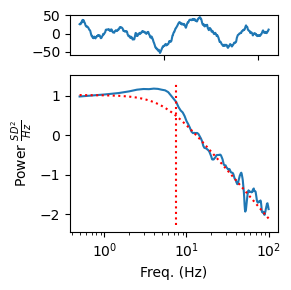

In [186]:
randix = rng.integers(0, high=respectra.shape[0])
spect_ts = np.linspace(s_pre,s_post,spect_ixs.shape[1])
# fit lorentzian
offset, knee, exponent = subdf.loc[randix,["offset","knee","exp"]]
aper_fit = lorentzian_function(f, offset, knee, exponent)
kf = 10**(compute_knee_frequency(knee, exponent))
# find channel indices that correspond to chosen spectrum
trial = randix//all_spect.shape[1]
stx = randix%all_spect.shape[1]
ttime = sts[stx]+s_pre
tx = np.argmin(np.abs(spect_ts-(np.sign(ttime)*ttime)))
bx = spect_ixs[trial,tx]
bxs = np.arange(bx-int(t_win*resrate/2),bx+int(t_win*resrate/2))

# plot channel data, spectrum, aperiodic fit
fig, ax = plt.subplots(2,1,figsize=(3,3),height_ratios=(1,4), tight_layout=True)

ax[0].plot(ts[bxs],bipolar[bxs])
ax[0].set_xticklabels([])
ax[1].plot(f,np.log10(respectra[randix,:]))
ax[1].plot(f,aper_fit, "r:")
ax[1].plot([kf,kf],ax[1].get_ylim(),"r:")
ax[1].set_xscale("log")
ax[1].set_xlabel("Freq. (Hz)")
ax[1].set_ylabel("Power "+ r'$\frac{SD^2}{Hz}$')

plt.show()

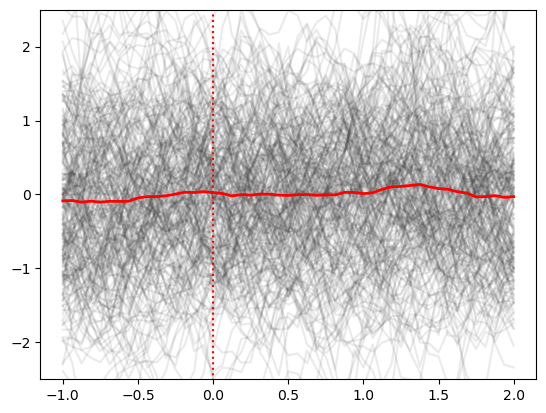

In [187]:
aper = subdf.exp.to_numpy().reshape(all_spect.shape[1:])
# plt.plot(sts+s_pre,exps[:,rng.integers(0,high=exps.shape[1])])
plt.plot(sts+s_pre,zscore(aper),color=[0.2,0.2,0.2,0.1])
plt.plot([0,0],plt.ylim(),"r:")
plt.plot(sts+s_pre,np.nanmean(zscore(aper),axis=1),"r",lw=2)
# plt.ylim([np.percentile(aper[~np.isnan(aper)],1), np.percentile(aper[~np.isnan(aper)],99)])
plt.ylim([-2.5,2.5])
plt.show()

In [226]:
aper.shape

(49, 240)

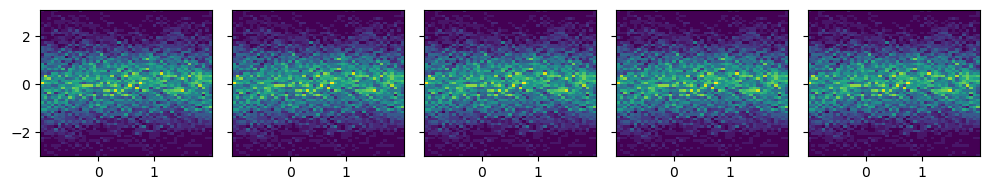

In [234]:
hbins = np.linspace(-3.05,3.05,62)
cats = events.img_category.unique()
fig,ax = plt.subplots(1,len(cats),figsize=(10,2),layout="tight")

for c,cat in enumerate(cats):
    cat_hists = []
    cat_ts = events.img_category==cat
    for ix in range(len(sts)):
        cat_hists.append(np.histogram(zscore(aper)[ix,cat_ts],hbins)[0])
    test = np.array(all_hists)
    ax[c].pcolormesh(sts+s_pre,hbins[1:],test.T, shading="nearest")
    ax[c].set_xticks([0,1])
    if c>0:
        ax[c].set_yticklabels([])
plt.show()

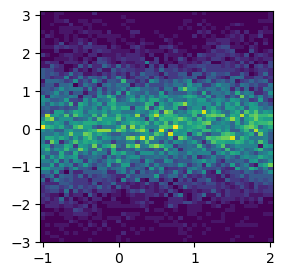

In [189]:
test = np.array(all_hists)
fig,ax = plt.subplots(figsize=(3,3))
ax.pcolormesh(sts+s_pre,hbins[1:],test.T, shading="nearest")
plt.show()

In [41]:
plot_param = "exp"
plotmat = subdf[plot_param].to_numpy().reshape(smoothspect.shape[1:])

In [241]:
off_mat.shape

(49, 240)

In [190]:
off_mat = subdf["offset"].to_numpy().reshape(smoothspect.shape[1:])
exp_mat = subdf["exp"].to_numpy().reshape(smoothspect.shape[1:])
k_mat = subdf["knee"].to_numpy().reshape(smoothspect.shape[1:])

81 anger


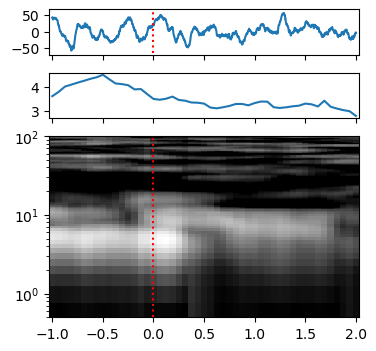

In [221]:
randix = np.random.randint(smoothspect.shape[2])
print(randix,events.img_category.iloc[randix])

spect_ts = np.linspace(s_pre,s_post,spect_ixs.shape[1])
tfilt = (spect_ts>s_pre+(t_win/2)) & (spect_ts<=s_post-(t_win/2))

randspect = np.log10(smoothspect[:,:,randix])
recons = np.array([lorentzian_function(f, off_mat[ix,randix], k_mat[ix,randix], exp_mat[ix,randix]) for ix in range(off_mat.shape[0])])
adj_spect = randspect-recons.T
adj_spect[adj_spect<=0] = 0

fig,axes = plt.subplots(nrows=3,ncols=1,height_ratios=[1,1,4],
                        sharex=True,figsize=(4,4))

axes[0].plot(spect_ts[tfilt],bipolar[spect_ixs[randix,tfilt]])
axes[1].plot(sts+s_pre,plotmat[:,randix])
axes[2].pcolormesh(sts+s_pre,f,adj_spect,cmap="grey",shading="nearest")
axes[2].set_ylim([0.5,100])
axes[2].plot([0,0],axes[2].get_ylim(),"r:")
axes[2].set_yscale("log")
# axes[0].set_ylim([-1,1])
axes[0].plot([0,0],axes[0].get_ylim(),"r:")
plt.show()

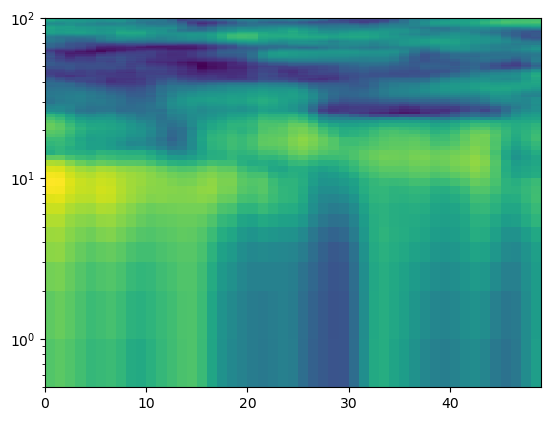

In [268]:
randix = np.random.randint(smoothspect.shape[2])
plt.pcolormesh(adj_spects[:,:,np.random.randint(smoothspect.shape[2])])
plt.ylim([0.5,100])
plt.yscale("log")
plt.show()

In [271]:
smoothspect.shape
adj_spects = np.zeros(smoothspect.shape)
for t in range(smoothspect.shape[2]):
    recons = np.array([lorentzian_function(f, off_mat[ix,t], k_mat[ix,t], exp_mat[ix,t]) for ix in range(smoothspect.shape[1])])
    adj_spects[:,:,t] = np.log10(smoothspect[:,:,t])-recons.T


0 anger
1 house
2 fear
3 happy
4 neutral


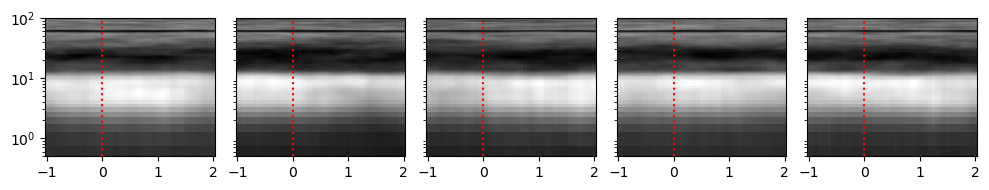

In [302]:
fig,ax = plt.subplots(1,len(cats),figsize=(10,2),layout="tight")
for c,cat in enumerate(cats):
    print(c, cat)
    catmat = adj_spects[:,:,events.img_category==cat].mean(axis=-1)
    ax[c].pcolormesh(sts+s_pre,f,catmat,
                       cmap="grey",shading="nearest")
    ax[c].set_ylim([0.5,100])
    ax[c].plot([0,0],ax[c].get_ylim(),"r:")
    ax[c].set_yscale("log")
    if c>0:
        ax[c].set_yticks([])
plt.show()

In [14]:
def plot_ERPs(ERP_mat,imgs,ERP_thresh,plot_ts,ixA,ixB):
    '''
    plot average ERP for each image category
    specify categories (array of strings)
    set threshold for SNR calculation
    use ixA and ixB as integer ixs for finding max/min
    '''

    if "house" in imgs.to_numpy():
        ERP_mat = ERP_mat[imgs!="house",:]
        imgs = imgs[imgs!="house"]
        
    img_cats = imgs.unique()
    img_cats.sort()
    
    fig,ax = plt.subplots(2,len(img_cats),tight_layout=True,figsize=(12,6),
                         sharex=True)
    cmap = plt.cm.grey
    vmin = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),2.5)
    vmax = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),97.5)
    xticks = np.linspace(min(plot_ts),max(plot_ts),7)
    yticks = np.round(ax[0,0].get_yticks(),decimals=2)
    pline = np.ones((len(plot_ts),))

    # make a dict of amplitudes and array of avg ERPs
    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    # iterate through image categories and plot
    for ix,cat in enumerate(img_cats):
        catmat = ERP_mat[imgs==cat,:]
        ERP = np.nanmean(catmat,axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ax[0,ix].plot(plot_ts,ERP)
        ax[0,ix].set_title(cat)
        ax[0,ix].scatter(plot_ts[max_ix],ERP[max_ix])
        ax[0,ix].scatter(plot_ts[min_ix],ERP[min_ix])
    
        ax[0,ix].fill_between(plot_ts, pline*(-ERP_thresh),
                           pline*(ERP_thresh),
                           color=[0.4,0.4,0.4,0.25]) 
        ax[1,ix].pcolormesh(plot_ts, range(catmat.shape[0]), catmat,
                            cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
   
    # do some axis organization and plot editing   
    [ax[0,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    ampval = np.max(np.abs(ERPs.flatten()))*1.125
    [ax[0,ix].set_ylim([-ampval,ampval]) for ix in range(ax.shape[1])]
    [ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
    [ax[0,ix].plot([0,0],ax[0,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    [ax[1,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].set_yticks([],labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].plot([0,0],ax[1,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    
    return ERP_amps,ax

img_category
anger      48
fear       48
happy      48
house      48
neutral    48
Name: block, dtype: int64
0.41967023247017016


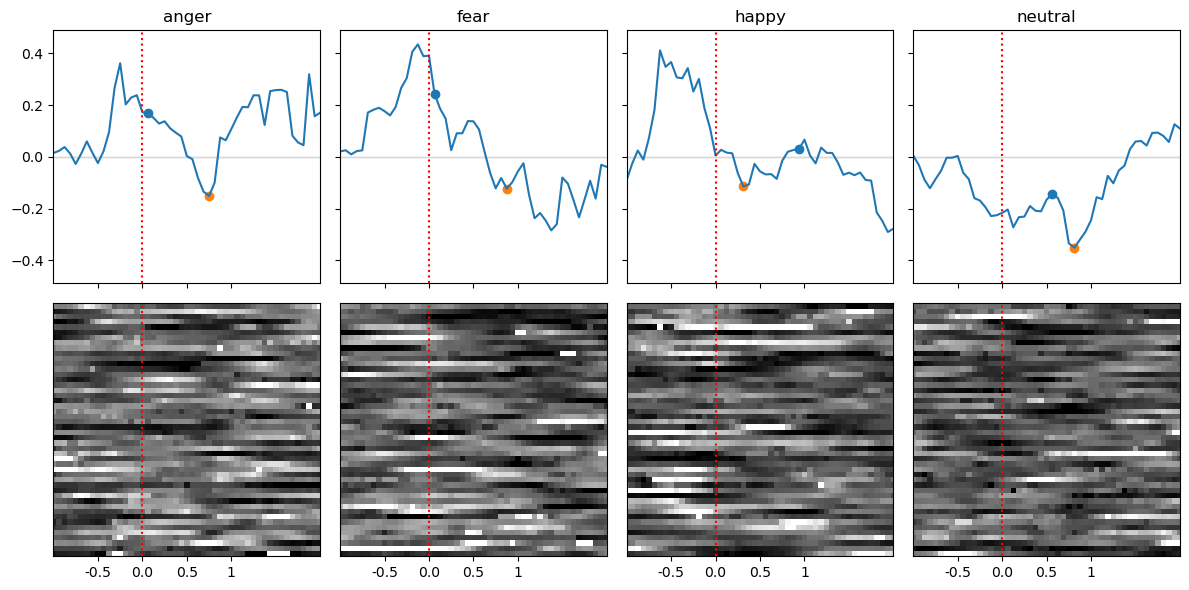

In [141]:

basestd = np.nanmean(zscore(plotmat[sts<=1,:]),axis=0).std()
# reset ixA to be slightly after image start
ixA = np.argmin(np.abs(sts+s_pre-0.05))
ixB = np.argmin(np.abs(sts+s_pre-1))
ERP_amps,ERP_ax = plot_ERPs(zscore(plotmat).T, events.img_category, 0,
                            sts+s_pre, ixA, ixB)
img_cats = np.array(["anger","fear","neutral","happy","house"])

print(events.groupby(by="img_category").block.count())

print(max(abs(np.array([ERP_amps[cat] for cat in img_cats[img_cats!="house"]]))/basestd))
[ERP_ax[0,ix].set_xlim([-1,2.0]) for ix in range(len(ERP_ax))]
[ERP_ax[0,ix].set_xticks([-0.5,0,0.5,1], labels=["-0.5","0.0","0.5","1"]) for ix in range(len(ERP_ax))]
plt.show()

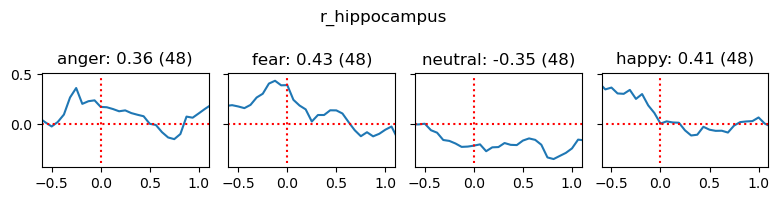

In [142]:
# ERP calculations
n_ts = events.groupby(by="img_category").block.count()
ix0 = np.argmin(np.where((sts+s_pre)>=0))
fig,ax = plt.subplots(1,len(img_cats[0:-1]),figsize=[8,2], tight_layout=True, sharey=True)
z_aper = zscore(plotmat)
for ix,cat in enumerate(img_cats[0:-1]):
    ERP_tfilt = np.nanmean(z_aper[:,(events.img_category==cat)],axis=1)
    max1 = np.argmax(np.abs(ERP_tfilt[ix0:]))+ix0
    ax[ix].plot(sts+s_pre,ERP_tfilt)
    ax[ix].plot(sts[[0,-1]]+s_pre,[0,0],"r:")
    # ax[ix].scatter(sts[max1]+s_pre,ERP_tfilt[max1],
    #                s=12,color="r",zorder=2)
    ax[ix].set_title(f"{cat}: {round(ERP_tfilt[max1],2)} ({n_ts.to_dict()[cat]})")

ylims = ax[-1].get_ylim()    
[ax[ix].plot([0,0],ylims,"r:") for ix in range(len(img_cats[0:-1]))] 
[ax[ix].set_xlim([-0.6,1.1]) for ix in range(len(img_cats[0:-1]))] 

reg = montage.region[montage.name==pair[0]].item()
fig.suptitle(reg)

plt.show()